In [19]:
from pathlib import Path
import sys


ROOT = Path.cwd().parent  # go from notebooks/ -> repo root
print("ROOT =", ROOT)

STEP3_DIR = ROOT / "src" / "03_add_noise"
if str(STEP3_DIR) not in sys.path:
    sys.path.insert(0, str(STEP3_DIR))
print("STEP3_DIR:", STEP3_DIR, "exists:", STEP3_DIR.exists())

from utils_noise import rms, speech_mask_from_intervals, EPS

ROOT = /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
STEP3_DIR: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/03_add_noise exists: True


In [20]:
import json
import numpy as np

def load_split(split: str, n: int = 200):
    split_dir = ROOT / "data" / "generated" / split
    manifest_path = split_dir / "manifests" / f"{split}_noisy_manifest.jsonl"
    rows = []
    with open(manifest_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n:
                break
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return split_dir, manifest_path, rows

split = "train"
split_dir, manifest_path, rows = load_split(split, n=3000)

clean_files  = list((split_dir/"clean_audio").glob("*.npy"))
noisy_files  = list((split_dir/"noisy_audio").glob("*.npy"))
label_files  = list((split_dir/"labels").glob("*_y.npy"))

print("Manifest:", manifest_path)
print("Counts clean/noisy/labels:", len(clean_files), len(noisy_files), len(label_files))
print("Rows loaded:", len(rows))

Manifest: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/train/manifests/train_noisy_manifest.jsonl
Counts clean/noisy/labels: 3000 3000 3000
Rows loaded: 3000


In [21]:
sr = 16000
frame_ms = 25.0
hop_ms = 10.0
L = int(frame_ms/1000 * sr)
H = int(hop_ms/1000 * sr)

label_mismatch = 0
peak_violations = 0
missing_files = 0

for r in rows:
    clean_path = split_dir / r["clean_audio_path"]
    noisy_path = split_dir / r["noisy_audio_path"]
    labels_path = split_dir / r["labels_path"]

    if not (clean_path.exists() and noisy_path.exists() and labels_path.exists()):
        missing_files += 1
        continue

    x_clean = np.load(clean_path).astype(np.float32, copy=False)
    x_noisy = np.load(noisy_path).astype(np.float32, copy=False)
    y = np.load(labels_path)

    expected_frames = (len(x_clean) - L)//H + 1
    if len(y) != expected_frames:
        label_mismatch += 1

    peak = float(np.max(np.abs(x_noisy))) if len(x_noisy) else 0.0
    if peak > 0.99 + 1e-3:
        peak_violations += 1

print("Missing referenced files:", missing_files)
print("Label length mismatches:", label_mismatch)
print("Peak violations (>0.99):", peak_violations)

Missing referenced files: 0
Label length mismatches: 0
Peak violations (>0.99): 0


In [22]:
from collections import Counter
import numpy as np

targets = []
actuals = []
abs_errs = []
noise_types = []
clip_applied = 0
noise_rms_nonspeech = []

for r in rows:
    x_clean = np.load(split_dir / r["clean_audio_path"]).astype(np.float32, copy=False)
    x_noisy = np.load(split_dir / r["noisy_audio_path"]).astype(np.float32, copy=False)

    mask = speech_mask_from_intervals(len(x_clean), r["speech_intervals"])
    if not np.any(mask):
        continue

    noise = r["noise"]
    target = float(noise["snr_db_target"])
    g = float(noise.get("clip_gain", 1.0))
    if g < 0.999999:
        clip_applied += 1

    # Undo clip gain before estimating noise
    n_eff = (x_noisy / g) - x_clean

    actual = 20*np.log10((rms(x_clean[mask]) + EPS) / (rms(n_eff[mask]) + EPS))

    targets.append(target)
    actuals.append(float(actual))
    abs_errs.append(abs(float(actual) - target))

    noise_types.append(noise.get("noise_type", "UNKNOWN"))

    if np.any(~mask):
        noise_rms_nonspeech.append(rms(x_noisy[~mask]))

print("Target bucket counts:", Counter(targets))
print("Mean |actual-target|:", float(np.mean(abs_errs)))
print("Clip applied count:", clip_applied, "/", len(rows))
print("Non-speech RMS mean:", float(np.mean(noise_rms_nonspeech)) if noise_rms_nonspeech else None)

Target bucket counts: Counter({10.0: 643, 20.0: 608, -5.0: 602, 0.0: 588, 5.0: 559})
Mean |actual-target|: 7.898365201851778e-06
Clip applied count: 627 / 3000
Non-speech RMS mean: 0.04044919522561855


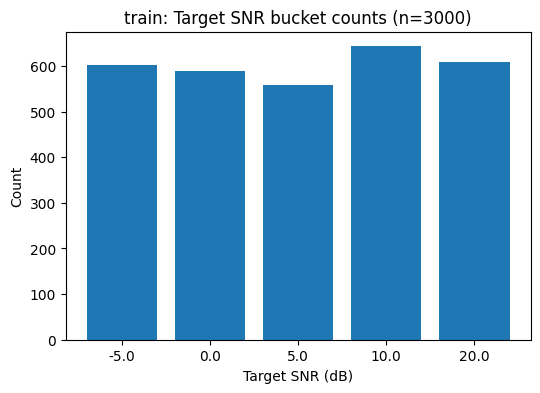

In [23]:
import matplotlib.pyplot as plt
from collections import Counter

c = Counter(targets)
xs = sorted(c.keys())
ys = [c[x] for x in xs]

plt.figure(figsize=(6,4))
plt.bar([str(x) for x in xs], ys)
plt.xlabel("Target SNR (dB)")
plt.ylabel("Count")
plt.title(f"{split}: Target SNR bucket counts (n={len(rows)})")
plt.show()

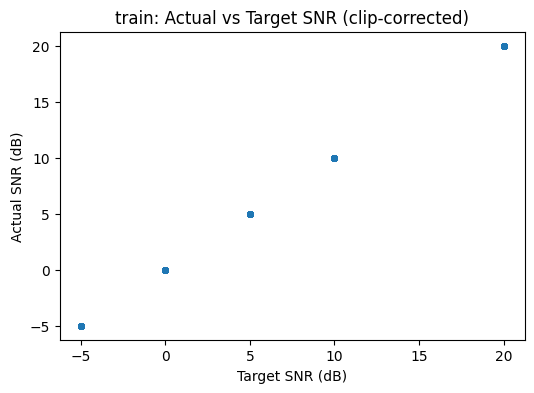

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(targets, actuals, s=14)
plt.xlabel("Target SNR (dB)")
plt.ylabel("Actual SNR (dB)")
plt.title(f"{split}: Actual vs Target SNR (clip-corrected)")
plt.show()

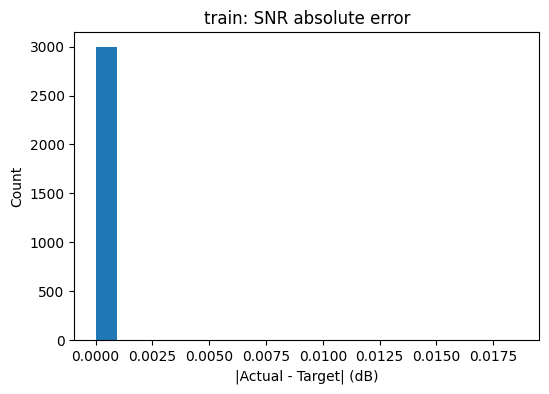

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(abs_errs, bins=20)
plt.xlabel("|Actual - Target| (dB)")
plt.ylabel("Count")
plt.title(f"{split}: SNR absolute error")
plt.show()

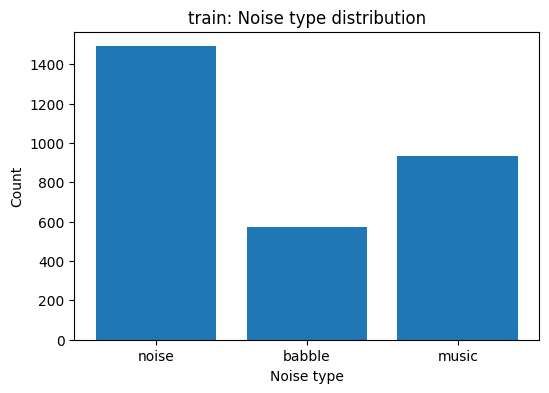

In [26]:
import matplotlib.pyplot as plt
from collections import Counter

ct = Counter(noise_types)
labels = list(ct.keys())
vals = [ct[k] for k in labels]

plt.figure(figsize=(6,4))
plt.bar(labels, vals)
plt.xlabel("Noise type")
plt.ylabel("Count")
plt.title(f"{split}: Noise type distribution")
plt.show()

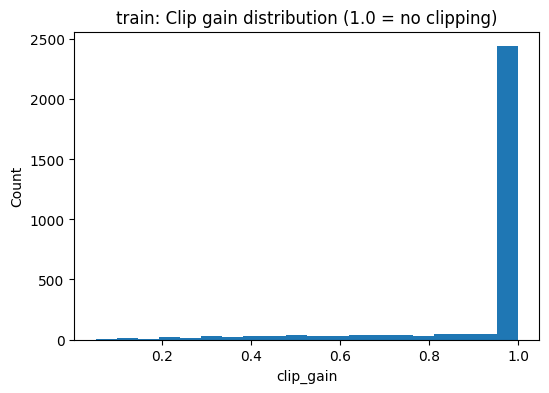

clip applied %: 20.9


In [27]:
import matplotlib.pyplot as plt

gains = [float(r["noise"].get("clip_gain", 1.0)) for r in rows]

plt.figure(figsize=(6,4))
plt.hist(gains, bins=20)
plt.xlabel("clip_gain")
plt.ylabel("Count")
plt.title(f"{split}: Clip gain distribution (1.0 = no clipping)")
plt.show()

print("clip applied %:", 100*sum(1 for g in gains if g < 0.999999)/len(gains))

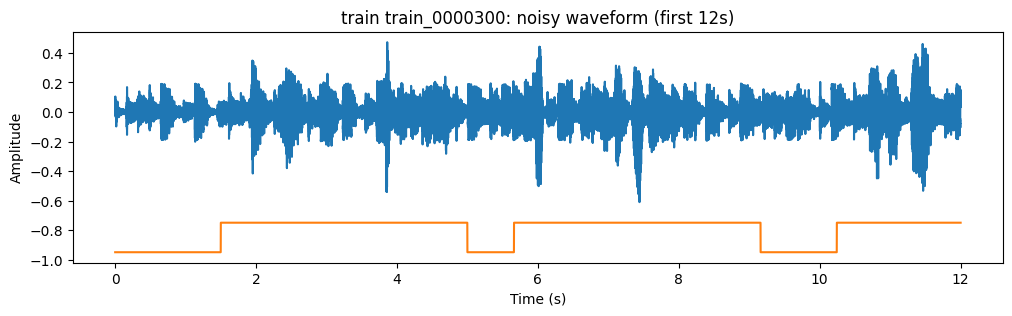

noise meta: {'noise_type': 'music', 'snr_db_target': 0.0, 'snr_db_actual': -7.973633112038596e-08, 'music_source': {'path': '/home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/raw/musan/music/rfm/music-rfm-0074.wav', 'crop_tile': {'mode': 'crop', 'start': 279069, 'orig_len': 2643174, 'target_len': 391675}}, 'scale_a': 0.21097214349841953, 'clip_gain': 1.0, 'rms_speech': 0.06427416909123879, 'rms_noise_speechregion_before_scale': 0.30465713636506386, 'peak_before_clipfix': 0.6107463836669922, 'max_peak': 0.99}


In [28]:
import numpy as np
import matplotlib.pyplot as plt

idx = 300
r = rows[idx]

x_noisy = np.load(split_dir / r["noisy_audio_path"]).astype(np.float32, copy=False)
mask = speech_mask_from_intervals(len(x_noisy), r["speech_intervals"])
sr = int(r.get("sr", 16000))

# show first N seconds
N_sec = 12
N = min(len(x_noisy), int(N_sec*sr))
t = np.arange(N) / sr

plt.figure(figsize=(12,3))
plt.plot(t, x_noisy[:N])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"{split} {r['ex_id']}: noisy waveform (first {N_sec}s)")

# overlay mask line (just a visual indicator)
mask_line = (mask[:N].astype(np.float32)*0.2) - 0.95
plt.plot(t, mask_line)
plt.show()

print("noise meta:", r["noise"])

len(E), len(y) = 1352 1352


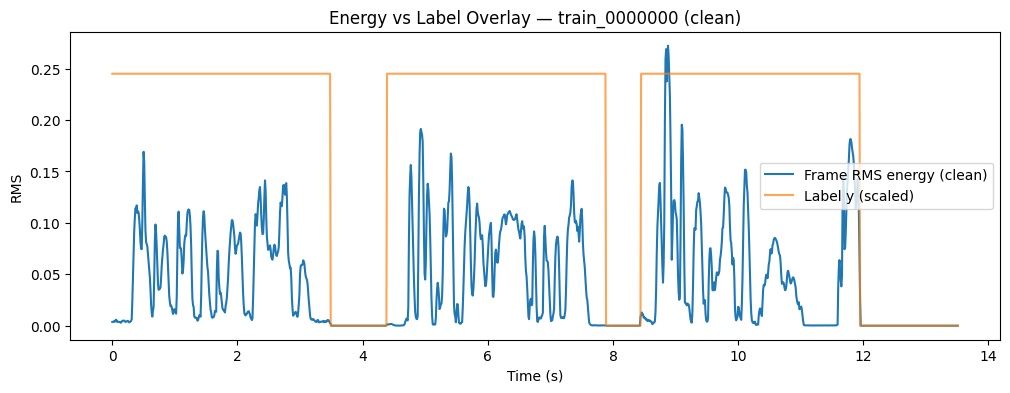

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def frame_rms(x: np.ndarray, frame_len: int, hop: int) -> np.ndarray:
    n = (len(x) - frame_len) // hop + 1
    out = np.empty(n, dtype=np.float32)
    for i in range(n):
        s = i * hop
        fr = x[s:s+frame_len]
        out[i] = np.sqrt(np.mean(fr.astype(np.float64)**2) + 1e-12)
    return out

# --- pick one example ---
r = rows[0]  # or any index
x = np.load(split_dir / r["clean_audio_path"]).astype(np.float32, copy=False)
y = np.load(split_dir / r["labels_path"]).astype(np.uint8, copy=False)

sr = int(r.get("sr", 16000))
frame_len = int(0.025 * sr)
hop = int(0.010 * sr)

E = frame_rms(x, frame_len, hop)

# Sanity: lengths should match
print("len(E), len(y) =", len(E), len(y))

t = np.arange(len(E)) * (hop / sr)  # frame times in seconds

plt.figure(figsize=(12,4))
plt.plot(t, E, label="Frame RMS energy (clean)")
plt.plot(t, y * (E.max() * 0.9), label="Label y (scaled)", alpha=0.7)  # overlay labels
plt.xlabel("Time (s)")
plt.ylabel("RMS")
plt.title(f"Energy vs Label Overlay — {r['ex_id']} (clean)")
plt.legend()
plt.show()

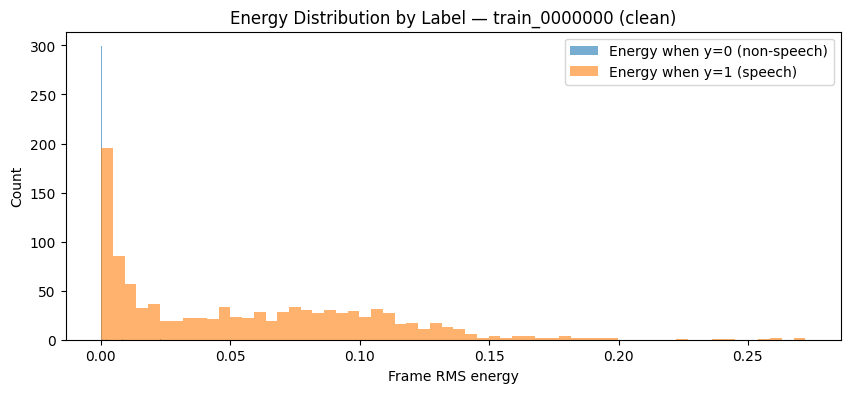

In [30]:
plt.figure(figsize=(10,4))
plt.hist(E[y==0], bins=60, alpha=0.6, label="Energy when y=0 (non-speech)")
plt.hist(E[y==1], bins=60, alpha=0.6, label="Energy when y=1 (speech)")
plt.xlabel("Frame RMS energy")
plt.ylabel("Count")
plt.title(f"Energy Distribution by Label — {r['ex_id']} (clean)")
plt.legend()
plt.show()

Speech-labeled frames with near-zero energy: 97 / 1352


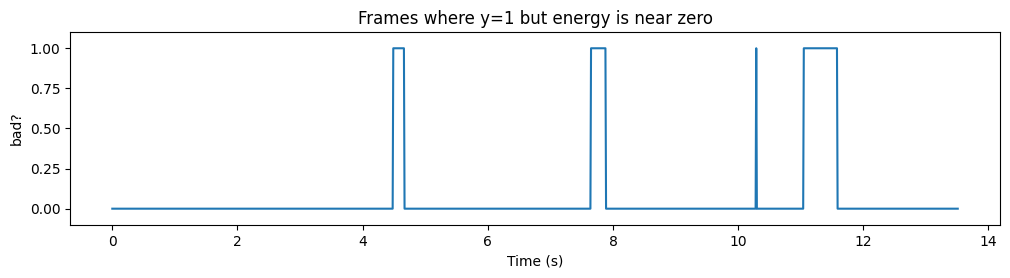

In [31]:
thr = 1e-3  # adjust if needed
bad = (y == 1) & (E < thr)

print("Speech-labeled frames with near-zero energy:", int(bad.sum()), "/", len(y))

# show where they occur
plt.figure(figsize=(12,2.5))
plt.plot(t, bad.astype(np.int8))
plt.ylim(-0.1, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("bad?")
plt.title("Frames where y=1 but energy is near zero")
plt.show()